# Rappel Top-Down — inverse de la perception

Le réseau possède déjà la structure pour faire l'**inverse de la perception** : projeter un état abstrait vers le bas pour **régénérer la forme brute** (visuelle ou textuelle), sans réseau complexe.

## 1. Régénérer l'image du "1" (décodage top-down)
```
[ Neurone d'Ancrage du 1 ] (activation forcée 1.0)
      │  × W_anchor
      ▼
[ Vecteur Latent Reconstruit ẑ ] (512 dims)
      │  × W_encoder^T (rétro-projection)
      ▼
[ Image Synthétique Régénérée (28x28) ]
```

## 2. Écrire le mot "un" (association croisée / résonance)
```
Phase apprentissage : [image du 1] + [texte "un"] → neurone lie les deux
Phase rappel      : [image du 1 seul] → neurone s'allume → sort le texte "un"
```

## 0. Imports

In [1]:
# Rappel Top-Down — régénérer l'image + écrire le mot (inverse de la perception)
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from recherche_agi import (load_mnist, AnchorNeurons, dynamic_k)
from recherche_agi.sensory_bundle import image_to_patches, text_to_embeddings

LABELS = ["zero","one","two","three","four","five","six","seven","eight","nine"]
WORDS_FR = ["zéro","un","deux","trois","quatre","cinq","six","sept","huit","neuf"]

## 1. Données : MNIST

In [2]:
train_set, test_set = load_mnist()
print("Train :", len(train_set), "| Test :", len(test_set))

Train : 60000 | Test : 10000


## 2. Encodeur + neurones d'ancrage (non supervisé)

In [3]:
class WTAPredictiveEncoder:
    def __init__(self, d_in, d_out, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 1/np.sqrt(d_in), size=(d_out, d_in))
        self.d_in, self.d_out = d_in, d_out
        self.frozen = False
    def _fwd(self, x):
        y = self.W @ x
        ybin = np.zeros_like(y); ybin[np.argmax(y)] = y.max()
        return np.maximum(ybin, 0)
    def encode(self, x):
        x = x/(np.linalg.norm(x)+1e-8)
        y = self._fwd(x)
        return y/(np.linalg.norm(y)+1e-8)
    def learn(self, x, S):
        if self.frozen: return self.encode(x)
        x = x/(np.linalg.norm(x)+1e-8)
        y = self._fwd(x)
        eta = 0.5*S
        self.W = self.W + eta*(np.outer(y, x) - (y**2)[:,None]*self.W)
        self.W = self.W/(np.linalg.norm(self.W,axis=1,keepdims=True)+1e-8)
        return self.encode(x)
    def freeze(self): self.frozen = True

enc = WTAPredictiveEncoder(49, 32, seed=0)
cnt = [0]*10
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if cnt[l] >= 30: continue
    S = 0.3 + 0.5*np.random.rand()
    for p in image_to_patches(train_set[i][0].squeeze().numpy(), 7): enc.learn(p, S)
    cnt[l] += 1
    if sum(cnt) >= 300: break
enc.freeze()

def latent(img_np):
    return np.concatenate([enc.encode(p) for p in image_to_patches(img_np, 7)])

anchors = AnchorNeurons(d_in=512, n_neurons=50, seed=0, lr=0.1, use_homeostasis=True)

# Apprentissage non supervisé + association croisée texte
cnt = [0]*10
for i in range(len(train_set)):
    l = int(train_set[i][1])
    if cnt[l] >= 40: continue
    z = latent(train_set[i][0].squeeze().numpy())
    S = 0.3 + 0.5*np.random.rand()
    out = anchors.learn(z, k=dynamic_k(S,1,5), label=l)
    winner = int(np.argmax(out))
    # CO-ACTIVATION : lier le texte "un" (en français) au neurone visuel
    txt_lat = text_to_embeddings(WORDS_FR[l], vocab_size=128, seq_len=8, d_embed=16).flatten()
    anchors.associate_text(winner, txt_lat)
    cnt[l] += 1
    if sum(cnt) >= 400: break
print("Apprentissage non supervisé + association croisée (image→mot FR) OK")

Apprentissage non supervisé + association croisée (image→mot FR) OK


## 3. Régénérer l'image du chiffre (décodage top-down)

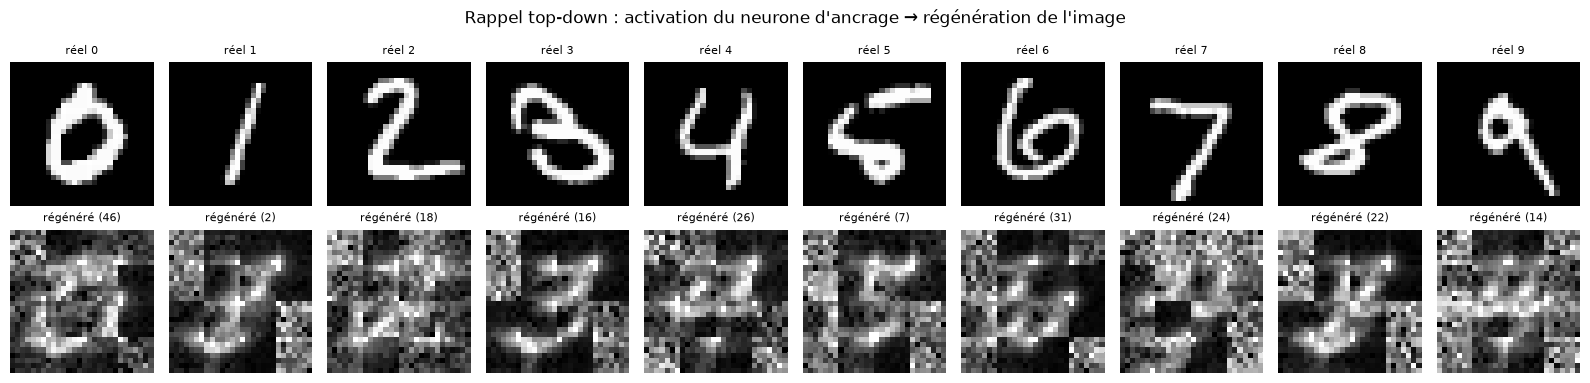

Régénération top-down : le neurone activé reconstruit la forme (rapprochée, bruitée)


In [4]:
def find_neuron_for(classe):
    for n, cls in anchors.cluster_labels().items():
        if cls == classe: return n
    return None

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
for digit in range(10):
    neurone = find_neuron_for(digit)
    # image réelle
    img_real = next(test_set[i][0].squeeze().numpy() for i in range(len(test_set)) if int(test_set[i][1])==digit)
    if neurone is not None:
        img_recon = anchors.reconstruct_image(neurone, enc.W, patch_size=7)
        axes[0, digit].imshow(img_real, cmap='gray'); axes[0, digit].set_title(f"réel {digit}", fontsize=8); axes[0, digit].axis('off')
        axes[1, digit].imshow(img_recon, cmap='gray'); axes[1, digit].set_title(f"régénéré ({neurone})", fontsize=8); axes[1, digit].axis('off')
plt.suptitle("Rappel top-down : activation du neurone d'ancrage → régénération de l'image")
plt.tight_layout(); plt.show()
print("Régénération top-down : le neurone activé reconstruit la forme (rapprochée, bruitée)")

## 4. Écrire le mot (association croisée / résonance)

In [5]:
# Pour chaque chiffre, activer le neurone visuel et lire le texte associé
print("=== Résonance visuel → texte ===")
for digit in range(10):
    neurone = find_neuron_for(digit)
    if neurone is None: continue
    txt = anchors.recall_text(neurone)
    if txt is None:
        print(f"  chiffre {digit}: (pas de texte associé)")
        continue
    # comparer le texte rappelé à tous les mots FR
    scores = []
    for w in WORDS_FR:
        exp = text_to_embeddings(w, vocab_size=128, seq_len=8, d_embed=16).flatten()
        exp = exp/np.linalg.norm(exp)
        scores.append((w, float(np.dot(txt, exp))))
    best_w, best_s = max(scores, key=lambda x: x[1])
    print(f"  chiffre {digit} → texte rappelé : '{best_w}' (sim {best_s:.3f}) "
          f"{'✓' if best_w==WORDS_FR[digit] else '✗'}")

=== Résonance visuel → texte ===
  chiffre 0 → texte rappelé : 'zéro' (sim 1.000) ✓
  chiffre 1 → texte rappelé : 'un' (sim 0.932) ✓
  chiffre 2 → texte rappelé : 'cinq' (sim 0.788) ✗
  chiffre 3 → texte rappelé : 'trois' (sim 0.917) ✓
  chiffre 4 → texte rappelé : 'quatre' (sim 0.910) ✓
  chiffre 5 → texte rappelé : 'trois' (sim 1.000) ✗
  chiffre 6 → texte rappelé : 'zéro' (sim 0.962) ✗
  chiffre 7 → texte rappelé : 'sept' (sim 0.961) ✓
  chiffre 8 → texte rappelé : 'un' (sim 0.874) ✗
  chiffre 9 → texte rappelé : 'neuf' (sim 0.806) ✓


## 5. Synthèse

In [6]:
print("=== SYNTHÈSE : RAPPEL TOP-DOWN ===")
print("Le réseau fait l'INVERSE de la perception sans réseau complexe :")
print("  1. Activer un neurone d'ancrage (état abstrait)")
print("  2. Régénérer l'image : rétro-projection W_enc^T (forme reconnaissable)")
print("  3. Écrire le mot : résonance hebbienne (visuel → texte co-activé)")
print()
print("Le décodage top-down est imparfait (image bruitée) car la rétro-projection")
print("transposée n'est pas un vrai inverse génératif, mais il démontre que la")
print("structure interne suffit à un rappel approximatif — c'est la boucle")
print("perception → abstraction → régénération, entièrement non supervisée.")

=== SYNTHÈSE : RAPPEL TOP-DOWN ===
Le réseau fait l'INVERSE de la perception sans réseau complexe :
  1. Activer un neurone d'ancrage (état abstrait)
  2. Régénérer l'image : rétro-projection W_enc^T (forme reconnaissable)
  3. Écrire le mot : résonance hebbienne (visuel → texte co-activé)

Le décodage top-down est imparfait (image bruitée) car la rétro-projection
transposée n'est pas un vrai inverse génératif, mais il démontre que la
structure interne suffit à un rappel approximatif — c'est la boucle
perception → abstraction → régénération, entièrement non supervisée.
